In [1]:
import os, re, random, hashlib, textwrap
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.feature_extraction.text import TfidfVectorizer

SEED = 42
random.seed(SEED); np.random.seed(SEED)
rng = np.random.default_rng(SEED)

DATA_DIR = "../dataset"
TRAIN_CSV = f"{DATA_DIR}/train.csv"
TEST_CSV = f"{DATA_DIR}/test.csv"
TRAIN_IMG_DIR = f"{DATA_DIR}/train_images"
TEST_IMG_DIR = f"{DATA_DIR}/test_images"

plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": 0.3})
pd.set_option("display.max_colwidth", 90)

In [2]:
for f in sorted(os.listdir(DATA_DIR)):
    p = os.path.join(DATA_DIR, f)
    print(f"{f:15s}", f"{len(os.listdir(p))} files" if os.path.isdir(p)
          else f"{os.path.getsize(p)/1e6:.2f} MB")

test.csv        0.00 MB
test_images     3 files
train.csv       4.75 MB
train_images    32412 files


In [3]:
train = pd.read_csv(TRAIN_CSV)
test = pd.read_csv(TEST_CSV)
print("train:", train.shape, "| test:", test.shape)
print("train columns:", list(train.columns))
print("test columns :", list(test.columns))
train.head()

train: (34250, 5) | test: (3, 4)
train columns: ['posting_id', 'image', 'image_phash', 'title', 'label_group']
test columns : ['posting_id', 'image', 'image_phash', 'title']


,posting_id,image,image_phash,title,label_group
0,train_129225211,0000a68812bc7e98c42888dfb1c07da0.jpg,94974f937d4c2433,Paper Bag Victoria Secret,249114794
1,train_3386243561,00039780dfc94d01db8676fe789ecd05.jpg,af3f9460c2838f0f,"Double Tape 3M VHB 12 mm x 4,5 m ORIGINAL / DOUBLE FOAM TAPE",2937985045
2,train_2288590299,000a190fdd715a2a36faed16e2c65df7.jpg,b94cb00ed3e50f78,Maling TTS Canned Pork Luncheon Meat 397 gr,2395904891
3,train_2406599165,00117e4fc239b1b641ff08340b429633.jpg,8514fc58eafea283,Daster Batik Lengan pendek - Motif Acak / Campur - Leher Kancing (DPT001-00) Batik kar...,4093212188
4,train_3369186413,00136d1cf4edede0203f32f05f660588.jpg,a6f319f924ad708c,Nescafe \xc3\x89clair Latte 220ml,3648931069


In [4]:
train.info()
print("\nNull values:\n", train.isnull().sum())
print("\nDuplicate posting_id:", train["posting_id"].duplicated().sum())
print("\ntest.csv:")
test

<class 'pandas.DataFrame'>
RangeIndex: 34250 entries, 0 to 34249
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   posting_id   34250 non-null  str  
 1   image        34250 non-null  str  
 2   image_phash  34250 non-null  str  
 3   title        34250 non-null  str  
 4   label_group  34250 non-null  int64
dtypes: int64(1), str(4)
memory usage: 5.4 MB

Null values:
 posting_id     0
image          0
image_phash    0
title          0
label_group    0
dtype: int64

Duplicate posting_id: 0

test.csv:


,posting_id,image,image_phash,title
0,test_2255846744,0006c8e5462ae52167402bac1c2e916e.jpg,ecc292392dc7687a,Edufuntoys - CHARACTER PHONE ada lampu dan musik/ mainan telepon
1,test_3588702337,0007585c4d0f932859339129f709bfdc.jpg,e9968f60d2699e2c,(Beli 1 Free Spatula) Masker Komedo | Blackheads Mask 10gr by Flawless Go Surabaya | F...
2,test_4015706929,0008377d3662e83ef44e1881af38b879.jpg,ba81c17e3581cabe,READY Lemonilo Mie instant sehat kuah dan goreng


In [5]:
group_sizes = train.groupby("label_group").size()

pos_pairs_total = int((group_sizes * (group_sizes - 1) // 2).sum())
all_pairs = len(train) * (len(train) - 1) // 2
print(f"Positive (same-product) pairs : {pos_pairs_total:,}")
print(f"All possible pairs            : {all_pairs:,}")
print(f"Positive pair rate            : {pos_pairs_total / all_pairs:.6%}")

ex_label = group_sizes[group_sizes >= 3].index[0]
print(f"\nExample: label_group = {ex_label}")
train[train["label_group"] == ex_label]

Positive (same-product) pairs : 83,751
All possible pairs            : 586,514,125
Positive pair rate            : 0.014279%

Example: label_group = 258047


,posting_id,image,image_phash,title,label_group
3874,train_1646767365,1d7aadc7503b2b4539cc9a5fe41979dd.jpg,e925873ed09cd08f,Sarung celana wadimor original 100% dewasa dan anak hitam dan putih polos,258047
6738,train_398181303,3301b8aaccea93d1098995ffbc537335.jpg,e9b5833e929e909c,SARUNG CELANA WADIMOR DEWASA HITAM POLOS SARCEL,258047
31859,train_1528423085,eec692257e74fcbc6cb63cb76d0f20e7.jpg,ea97861c926a71e3,WARNA RANDOM ACAK Sarung Celana Wadimor MURAH Celana Sarung WADIMOR,258047


## Statistical Analysis

In [6]:
def norm_title(s):
    return re.sub(r"\s+", " ", str(s).lower()).strip()

train["title_norm"] = train["title"].map(norm_title)
train["phash_int"] = np.array([int(h, 16) for h in train["image_phash"]], dtype=np.uint64)

summary = {
    "Listings (rows)": len(train),
    "Unique posting_id": train["posting_id"].nunique(),
    "Unique product groups (label_group)": train["label_group"].nunique(),
    "Unique image file names": train["image"].nunique(),
    "Unique image_phash": train["image_phash"].nunique(),
    "Unique titles (raw)": train["title"].nunique(),
    "Unique titles (lowercased, whitespace-normalised)": train["title_norm"].nunique(),
    "Avg listings per group": round(group_sizes.mean(), 2),
    "Median listings per group": group_sizes.median(),
    "Min / Max group size": f"{group_sizes.min()} / {group_sizes.max()}",
}
pd.Series(summary).to_frame("value")

,value
Listings (rows),34250
Unique posting_id,34250
Unique product groups (label_group),11014
Unique image file names,32412
Unique image_phash,28735
Unique titles (raw),33117
"Unique titles (lowercased, whitespace-normalised)",32594
Avg listings per group,3.11
Median listings per group,2.0
Min / Max group size,2 / 51


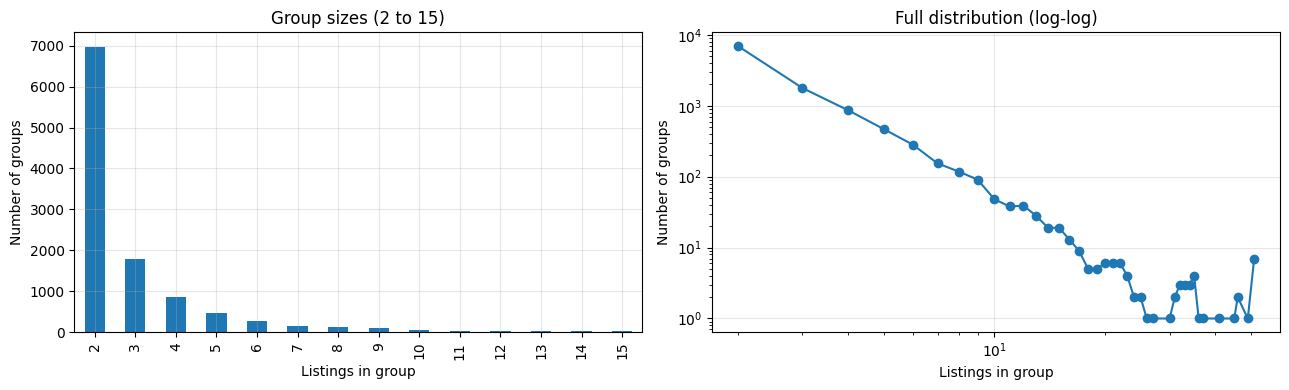

count    11014.000000
mean         3.109679
std          2.940827
min          2.000000
25%          2.000000
50%          2.000000
75%          3.000000
max         51.000000
dtype: float64

Groups of size 2      : 63.4%
Groups of size <= 3   : 79.5%
Rows in groups >= 10  : 13.5%


In [7]:
size_counts = group_sizes.value_counts().sort_index()

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
size_counts.loc[:15].plot.bar(ax=ax[0], color="tab:blue")
ax[0].set_title("Group sizes (2 to 15)")
ax[0].set_xlabel("Listings in group"); ax[0].set_ylabel("Number of groups")

ax[1].loglog(size_counts.index, size_counts.values, "o-")
ax[1].set_title("Full distribution (log-log)")
ax[1].set_xlabel("Listings in group"); ax[1].set_ylabel("Number of groups")
plt.tight_layout(); plt.show()

print(group_sizes.describe())
print(f"\nGroups of size 2      : {(group_sizes == 2).mean():.1%}")
print(f"Groups of size <= 3   : {(group_sizes <= 3).mean():.1%}")
print(f"Rows in groups >= 10  : {group_sizes[group_sizes >= 10].sum() / len(train):.1%}")

,dup_keys,rows_involved,pure_keys,mixed_keys,purity_%
img_md5,1246.0,3084.0,1200.0,46.0,96.3
image_phash,3229.0,8744.0,3082.0,147.0,95.4
title_norm,1337.0,2993.0,1231.0,106.0,92.1


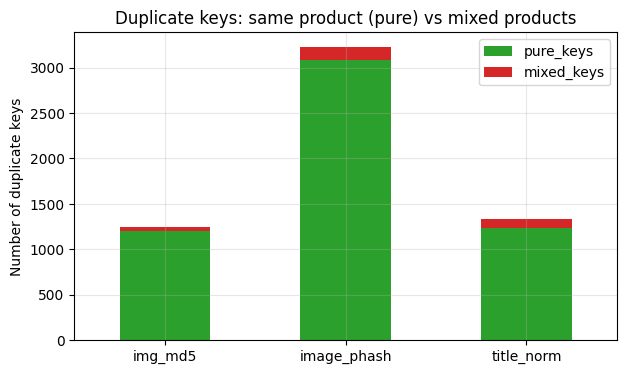

In [8]:
def md5_file(path):
    h = hashlib.md5()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1 << 20), b""):
            h.update(chunk)
    return h.hexdigest()

train["img_md5"] = [md5_file(f"{TRAIN_IMG_DIR}/{f}") for f in train["image"]]

def dup_purity(df, col):
    """Duplicate keys ke rows kitne baar same label_group me aate hain."""
    g = df.groupby(col)["label_group"].agg(["size", "nunique"])
    d = g[g["size"] > 1]
    return pd.Series({
        "dup_keys": len(d),
        "rows_involved": int(d["size"].sum()),
        "pure_keys": int((d["nunique"] == 1).sum()),
        "mixed_keys": int((d["nunique"] > 1).sum()),
        "purity_%": round(100 * (d["nunique"] == 1).mean(), 1),
    })

purity = pd.DataFrame({c: dup_purity(train, c) for c in ["img_md5", "image_phash", "title_norm"]}).T
display(purity)

purity[["pure_keys", "mixed_keys"]].plot.bar(stacked=True, figsize=(7, 4),
        color=["tab:green", "tab:red"], title="Duplicate keys: same product (pure) vs mixed products")
plt.ylabel("Number of duplicate keys"); plt.xticks(rotation=0); plt.show()

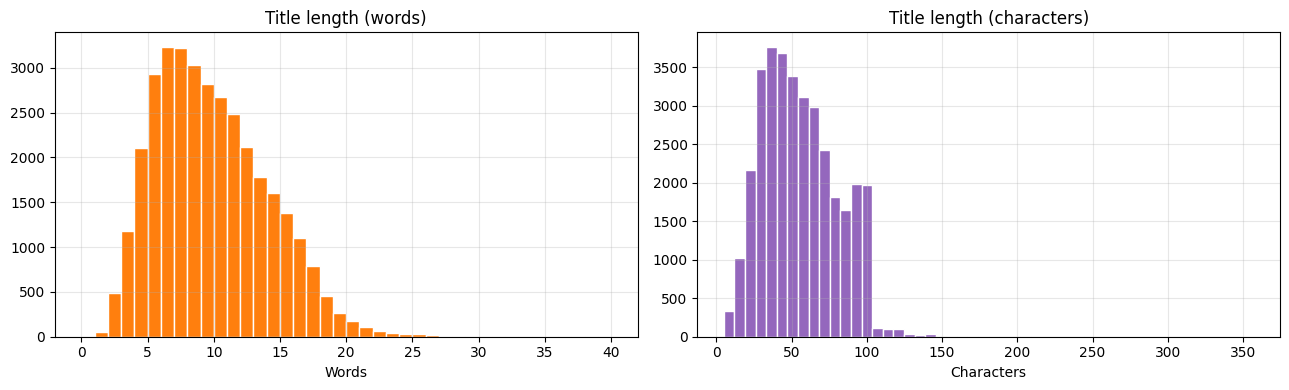

,n_words,n_chars
count,34250.000000,34250.000000
mean,9.414861,56.163474
std,4.446719,25.100492
min,1.000000,5.000000
25%,6.000000,36.000000
50%,9.000000,53.000000
75%,12.000000,73.000000
max,61.000000,357.000000


In [9]:
train["n_words"] = train["title_norm"].str.split().str.len()
train["n_chars"] = train["title"].str.len()

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].hist(train["n_words"], bins=range(0, 41), color="tab:orange", edgecolor="white")
ax[0].set_title("Title length (words)"); ax[0].set_xlabel("Words")
ax[1].hist(train["n_chars"], bins=50, color="tab:purple", edgecolor="white")
ax[1].set_title("Title length (characters)"); ax[1].set_xlabel("Characters")
plt.tight_layout(); plt.show()

train[["n_words", "n_chars"]].describe()

In [11]:
import re
from collections import Counter

train["title"] = train["title"].fillna("").astype(str)
train["title_norm"] = train["title_norm"].fillna("").astype(str)

train["non_ascii"] = train["title"].map(
    lambda s: any(ord(c) > 127 for c in s)
)

train["has_cjk"] = train["title"].map(
    lambda s: bool(re.search(r"[\u4e00-\u9fff]", s))
)


def upper_ratio(s):
    letters = [c for c in s if c.isalpha()]
    return sum(c.isupper() for c in letters) / len(letters) if letters else 0.0


train["upper_ratio"] = train["title"].map(upper_ratio)

train["special_ratio"] = train["title"].map(
    lambda s: sum(
        not (c.isalnum() or c.isspace())
        for c in s
    ) / max(len(s), 1)
)

train["has_digit"] = train["title"].str.contains(
    r"\d",
    regex=True
)

PROMO = (
    r"\b(?:promo|murah|termurah|diskon|sale|gratis|free|ready|"
    r"stok|stock|grosir|cod|ongkir|baru|new|original|ori|"
    r"best seller|bestseller|hot)\b"
)

train["has_promo"] = train["title_norm"].str.contains(
    PROMO,
    regex=True,
    case=False
)

for col in ["non_ascii", "has_cjk", "has_digit", "has_promo"]:
    print(f"{col:10s}: {train[col].mean():.1%}")

print(
    f"mostly upper-case (>80% letters): "
    f"{(train['upper_ratio'] > 0.8).mean():.1%}"
)

print(
    f"special-char ratio > 15%        : "
    f"{(train['special_ratio'] > 0.15).mean():.1%}"
)

non_ascii : 0.0%
has_cjk   : 0.0%
has_digit : 59.0%
has_promo : 19.5%
mostly upper-case (>80% letters): 21.2%
special-char ratio > 15%        : 0.3%


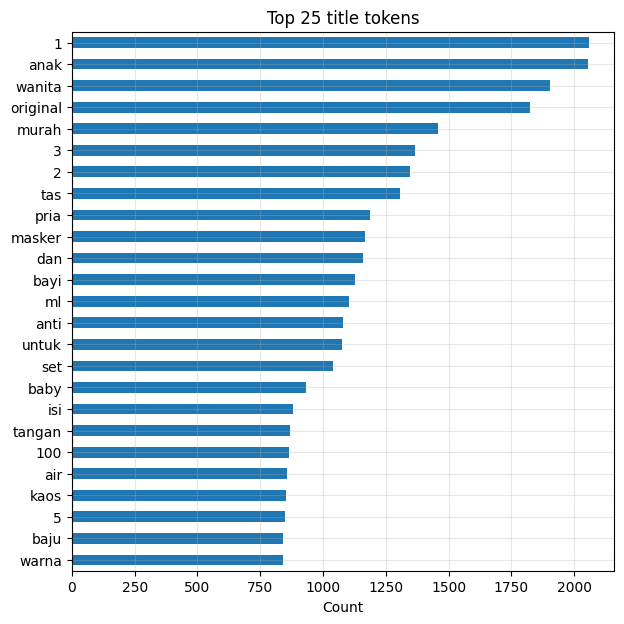

In [12]:
words = Counter(
    w
    for t in train["title_norm"]
    for w in re.findall(r"\w+", t)
)

top = pd.Series(
    dict(words.most_common(25))
)[::-1]

top.plot.barh(
    figsize=(7, 7),
    title="Top 25 title tokens"
)

plt.xlabel("Count")
plt.show()

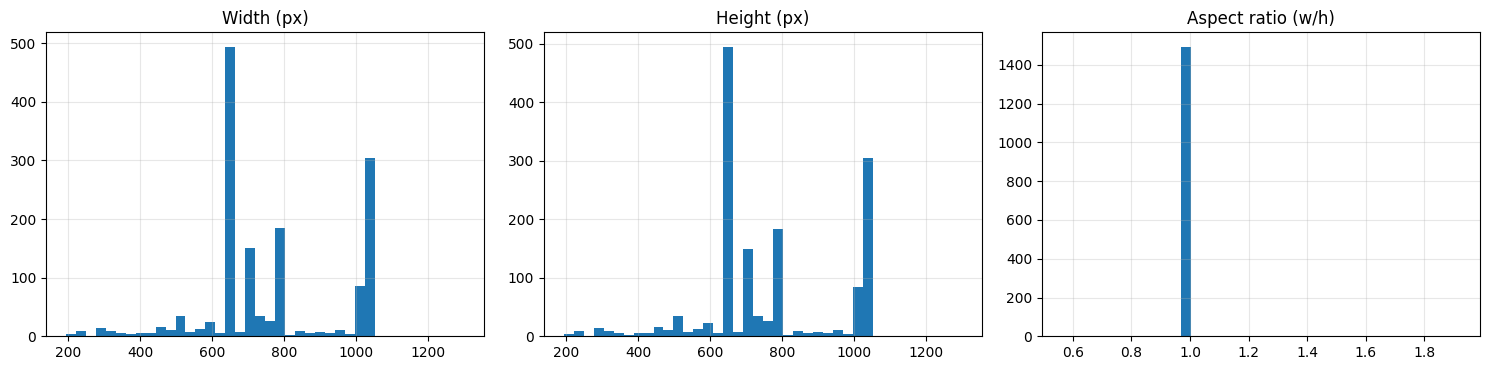

Non-square images     : 0.5%
Min side < 300 px     : 0.9%
Unique (w,h) combos   : 193


In [13]:
img_samp = rng.choice(len(train), 1500, replace=False)
img_w, img_h = [], []
for i in img_samp:
    with Image.open(f"{TRAIN_IMG_DIR}/{train.loc[i, 'image']}") as im:
        img_w.append(im.size[0]); img_h.append(im.size[1])
img_w, img_h = np.array(img_w), np.array(img_h)

fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))
ax[0].hist(img_w, bins=40); ax[0].set_title("Width (px)")
ax[1].hist(img_h, bins=40); ax[1].set_title("Height (px)")
ax[2].hist(img_w / img_h, bins=40); ax[2].set_title("Aspect ratio (w/h)")
plt.tight_layout(); plt.show()

print(f"Non-square images     : {(img_w != img_h).mean():.1%}")
print(f"Min side < 300 px     : {(np.minimum(img_w, img_h) < 300).mean():.1%}")
print(f"Unique (w,h) combos   : {len(set(zip(img_w, img_h)))}")

In [14]:
train["phash_twin"] = train.groupby(["label_group", "image_phash"])["posting_id"].transform("size") > 1
train["title_twin"] = train.groupby(["label_group", "title_norm"])["posting_id"].transform("size") > 1
train["any_twin"] = train["phash_twin"] | train["title_twin"]

print(f"Rows with same-group twin by pHash      : {train['phash_twin'].mean():.1%}")
print(f"Rows with same-group twin by exact title: {train['title_twin'].mean():.1%}")
print(f"Rows with a twin by either              : {train['any_twin'].mean():.1%}")
print(f"Rows with NO exact twin (hard rows)     : {(~train['any_twin']).mean():.1%}")

Rows with same-group twin by pHash      : 24.9%
Rows with same-group twin by exact title: 8.2%
Rows with a twin by either              : 31.6%
Rows with NO exact twin (hard rows)     : 68.4%


## Product Similarity investigation

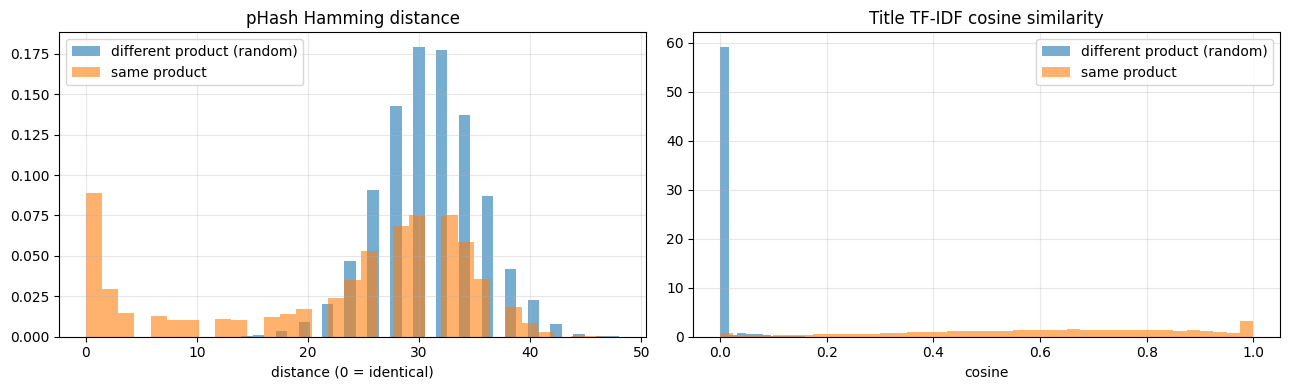

Same-product pairs with pHash dist <= 4 : 19.4%
Same-product pairs with pHash dist > 16 : 70.9%
Same-product pairs with title cos < 0.2 : 6.5%
Same-product pairs with BOTH (dist>16 & cos<0.2): 4.5%


In [15]:
# --- Text: TF-IDF (L2-normalised, so dot product = cosine) ---
tfidf = TfidfVectorizer(token_pattern=r"(?u)\b\w+\b", sublinear_tf=True, min_df=2)
X = tfidf.fit_transform(train["title_norm"])

# --- Image: pHash Hamming distance ---
ph = train["phash_int"].values
labels = train["label_group"].values
POP = np.array([bin(i).count("1") for i in range(256)], dtype=np.uint8)

def hamming(a, b):
    x = np.ascontiguousarray(np.bitwise_xor(a, b))
    return POP[x.view(np.uint8).reshape(x.shape + (8,))].sum(-1, dtype=np.int32)

def pair_cos(a, b):
    return np.asarray(X[a].multiply(X[b]).sum(1)).ravel()

# One random positive pair per group
pos_a, pos_b = [], []
for lbl, idx in train.groupby("label_group").indices.items():
    a, b = rng.choice(idx, 2, replace=False)
    pos_a.append(a); pos_b.append(b)
pos_a, pos_b = np.array(pos_a), np.array(pos_b)

# Random negative pairs
neg_a = rng.integers(0, len(train), len(pos_a))
neg_b = rng.integers(0, len(train), len(pos_a))
m = labels[neg_a] != labels[neg_b]
neg_a, neg_b = neg_a[m], neg_b[m]

pos_ham, neg_ham = hamming(ph[pos_a], ph[pos_b]), hamming(ph[neg_a], ph[neg_b])
pos_cos, neg_cos = pair_cos(pos_a, pos_b), pair_cos(neg_a, neg_b)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].hist(neg_ham, bins=33, alpha=0.6, density=True, label="different product (random)")
ax[0].hist(pos_ham, bins=33, alpha=0.6, density=True, label="same product")
ax[0].set_title("pHash Hamming distance"); ax[0].set_xlabel("distance (0 = identical)"); ax[0].legend()
ax[1].hist(neg_cos, bins=40, alpha=0.6, density=True, label="different product (random)")
ax[1].hist(pos_cos, bins=40, alpha=0.6, density=True, label="same product")
ax[1].set_title("Title TF-IDF cosine similarity"); ax[1].set_xlabel("cosine"); ax[1].legend()
plt.tight_layout(); plt.show()

print(f"Same-product pairs with pHash dist <= 4 : {(pos_ham <= 4).mean():.1%}")
print(f"Same-product pairs with pHash dist > 16 : {(pos_ham > 16).mean():.1%}")
print(f"Same-product pairs with title cos < 0.2 : {(pos_cos < 0.2).mean():.1%}")
print(f"Same-product pairs with BOTH (dist>16 & cos<0.2): {((pos_ham > 16) & (pos_cos < 0.2)).mean():.1%}")

In [16]:
N_ANCH, K = 3000, 10
anchors = rng.choice(len(train), N_ANCH, replace=False)
anch_lab = labels[anchors]
gsize = group_sizes.reindex(anch_lab).values

def topk(S, k, largest):
    sg = -1 if largest else 1
    idx = np.argpartition(sg * S, k, axis=1)[:, :k]
    vals = np.take_along_axis(S, idx, 1)
    order = np.argsort(sg * vals, axis=1)
    return np.take_along_axis(idx, order, 1), np.take_along_axis(vals, order, 1)

text_nn = np.zeros((N_ANCH, K), dtype=int); text_sim = np.zeros((N_ANCH, K))
for s in range(0, N_ANCH, 300):
    a = anchors[s:s + 300]
    S = (X[a] @ X.T).toarray()
    S[np.arange(len(a)), a] = -1                      # self exclude
    text_nn[s:s + len(a)], text_sim[s:s + len(a)] = topk(S, K, True)

ph_nn = np.zeros((N_ANCH, K), dtype=int); ph_dist = np.zeros((N_ANCH, K))
for s in range(0, N_ANCH, 200):
    a = anchors[s:s + 200]
    D = hamming(ph[a][:, None], ph[None, :]).astype(np.int32)
    D[np.arange(len(a)), a] = 999
    ph_nn[s:s + len(a)], ph_dist[s:s + len(a)] = topk(D, K, False)

def eval_nn(nn):
    hit = labels[nn] == anch_lab[:, None]
    p1 = hit[:, 0].mean()
    rec = (hit.sum(1) / np.minimum(K, gsize - 1)).mean()
    return p1, rec, hit[:, 0]

text_p1, text_rec, t_hit = eval_nn(text_nn)
ph_p1, ph_rec, p_hit = eval_nn(ph_nn)
either = (t_hit | p_hit).mean()

print(pd.DataFrame({
    "P@1": [text_p1, ph_p1], f"Recall@{K}": [text_rec, ph_rec]},
    index=["Title (TF-IDF) only", "Image (pHash) only"]).round(3))
print(f"\nTop-1 correct by text OR image : {either:.1%}")
print(f"Top-1 wrong for BOTH           : {1 - either:.1%}")

rows = []
for t in [0, 2, 4, 6, 8, 10, 14]:
    mk = ph_dist[:, 0] <= t
    rows.append((f"pHash dist <= {t}", mk.mean(), p_hit[mk].mean() if mk.any() else np.nan))
for t in [0.95, 0.8, 0.6, 0.4]:
    mk = text_sim[:, 0] >= t
    rows.append((f"title cosine >= {t}", mk.mean(), t_hit[mk].mean() if mk.any() else np.nan))
pd.DataFrame(rows, columns=["rule", "coverage", "precision"]).round(3)

                       P@1  Recall@10
Title (TF-IDF) only  0.683      0.784
Image (pHash) only   0.373      0.289

Top-1 correct by text OR image : 78.8%
Top-1 wrong for BOTH           : 21.2%


,rule,coverage,precision
0,pHash dist <= 0,0.245,0.969
1,pHash dist <= 2,0.298,0.957
2,pHash dist <= 4,0.328,0.945
3,pHash dist <= 6,0.363,0.910
4,pHash dist <= 8,0.403,0.867
5,pHash dist <= 10,0.471,0.769
6,pHash dist <= 14,0.857,0.434
7,title cosine >= 0.95,0.170,0.914
8,title cosine >= 0.8,0.457,0.850
9,title cosine >= 0.6,0.799,0.756


In [17]:
def load_img(fname):
    try:
        return Image.open(f"{TRAIN_IMG_DIR}/{fname}").convert("RGB")
    except Exception:
        return Image.new("RGB", (100, 100), "gray")

def show_grid(indices, ncols, header, notes=None, wrap=34):
    indices = list(indices)
    if len(indices) == 0:
        print("No examples found for:", header); return
    nrows = int(np.ceil(len(indices) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.1 * ncols, 3.6 * nrows), squeeze=False)
    for ax in axes.ravel():
        ax.axis("off")
    for k, i in enumerate(indices):
        ax = axes.ravel()[k]
        r = train.iloc[i]
        ax.imshow(load_img(r["image"]))
        t = f"grp {r['label_group']}\n" + textwrap.fill(
            textwrap.shorten(r["title"], 90, placeholder="..."), wrap)
        if notes and notes[k]:
            t += "\n" + notes[k]
        ax.set_title(t, fontsize=7)
    fig.suptitle(header, fontsize=12)
    plt.tight_layout(); plt.show()

def show_pairs(pairs, header, notes=None):
    flat = [x for p in pairs for x in p]
    nts = None if notes is None else [n for n in notes for _ in (0, 1)]
    show_grid(flat, 2, header, nts)

def diff_tokens(i, j):
    a, b = set(train["title_norm"].iloc[i].split()), set(train["title_norm"].iloc[j].split())
    return sorted(a - b), sorted(b - a)

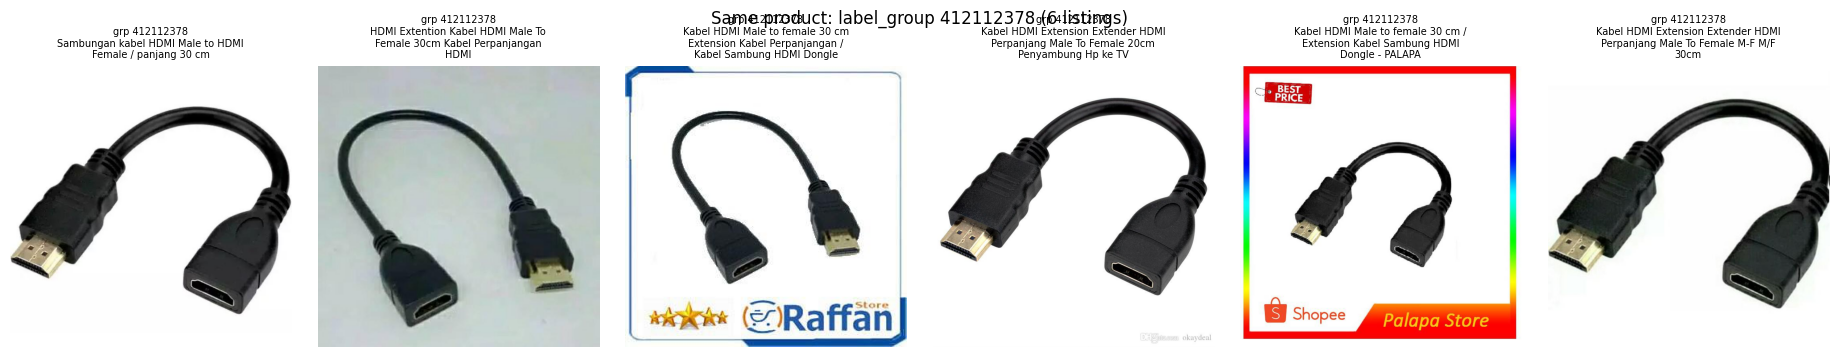

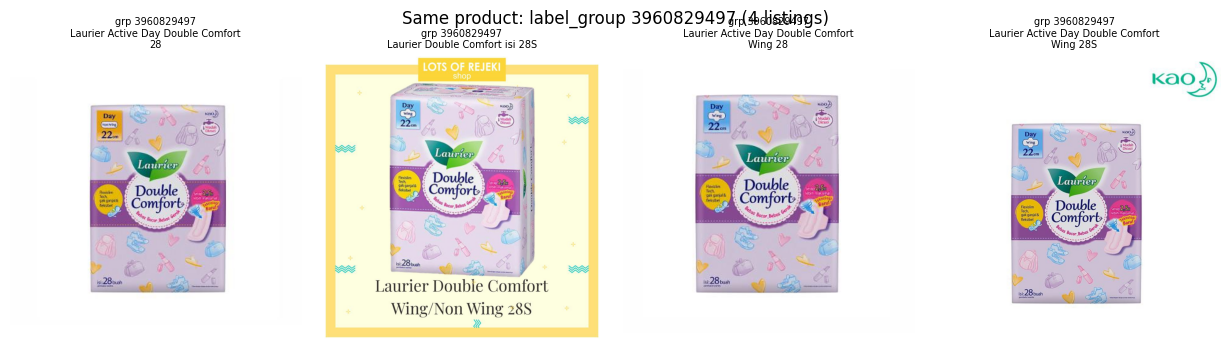

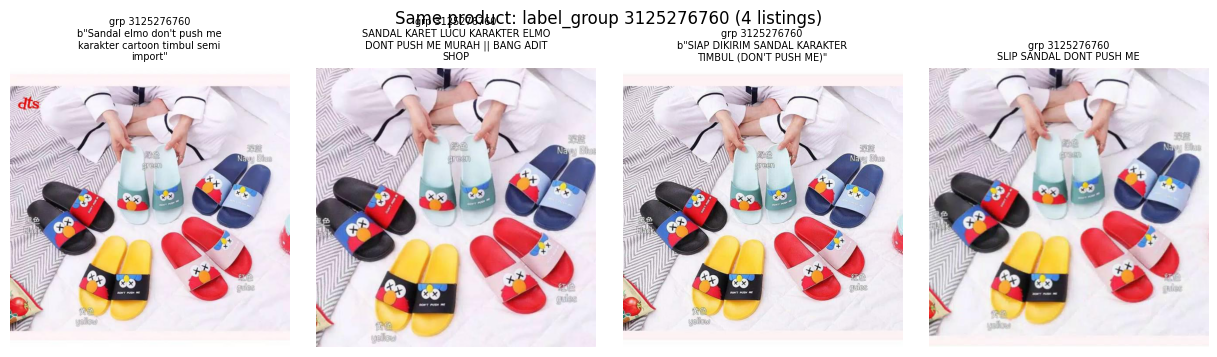

In [18]:
cands = group_sizes[(group_sizes >= 4) & (group_sizes <= 6)].index.values
for lbl in rng.choice(cands, 3, replace=False):
    idx = np.where(labels == lbl)[0]
    show_grid(idx, len(idx), f"Same product: label_group {lbl} ({len(idx)} listings)")

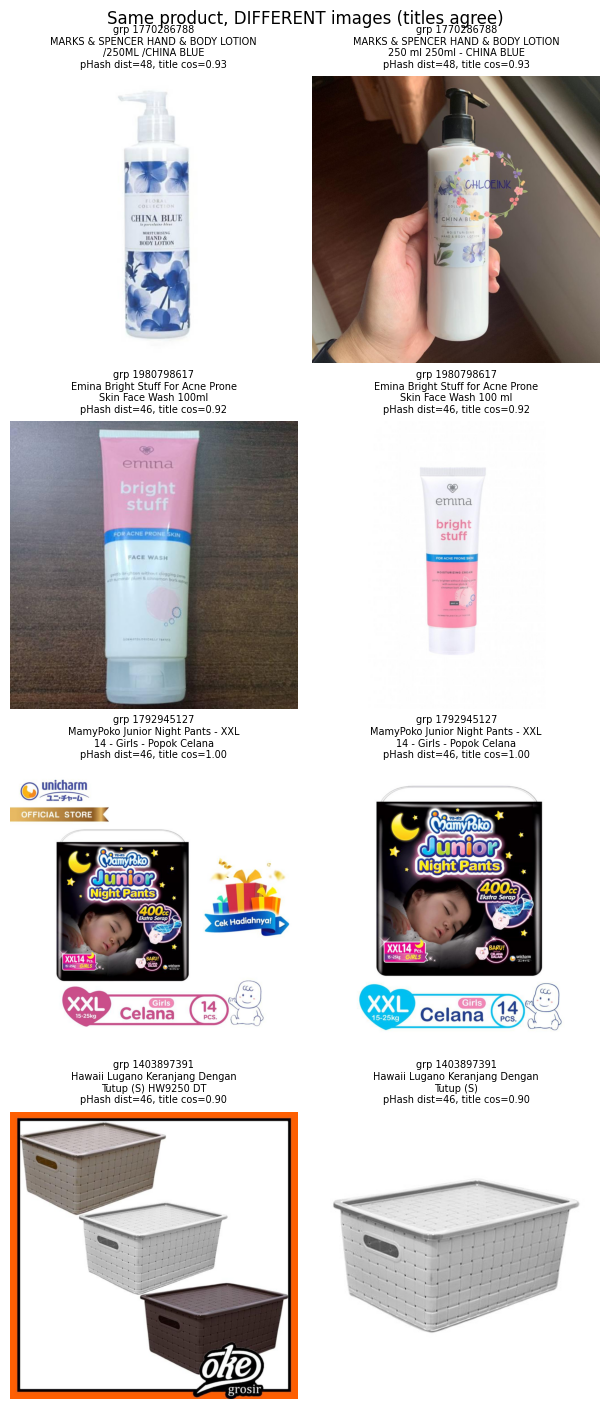

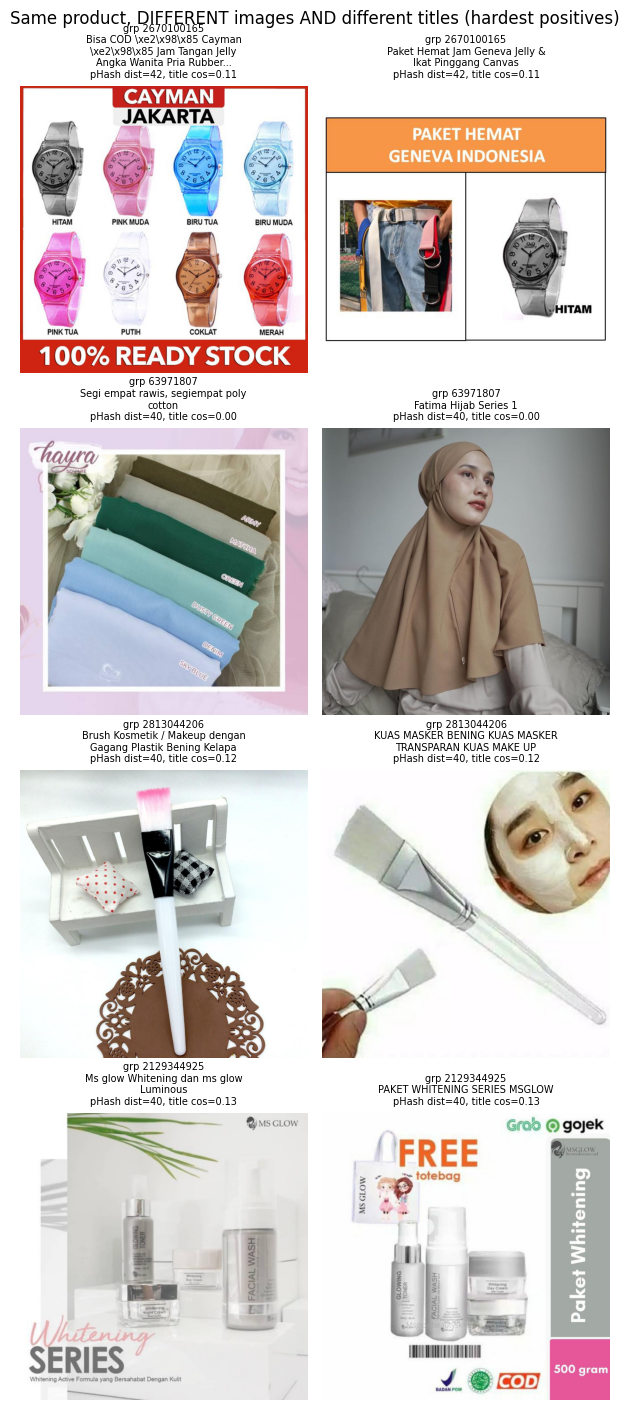

In [19]:
## Same product , different images

order = np.argsort(-pos_ham)

# (a) images bahut alag, par titles agree karte hain
ks = [k for k in order if pos_cos[k] >= 0.5][:4]
show_pairs([(pos_a[k], pos_b[k]) for k in ks],
           "Same product, DIFFERENT images (titles agree)",
           [f"pHash dist={pos_ham[k]}, title cos={pos_cos[k]:.2f}" for k in ks])

# (b) hardest positives: images bhi alag, titles bhi alag
ks2 = [k for k in order if pos_cos[k] < 0.15][:4]
show_pairs([(pos_a[k], pos_b[k]) for k in ks2],
           "Same product, DIFFERENT images AND different titles (hardest positives)",
           [f"pHash dist={pos_ham[k]}, title cos={pos_cos[k]:.2f}" for k in ks2])

Anchors jinka top-1 title-neighbour cos>=0.6 hai par DIFFERENT product: 548 / 3000


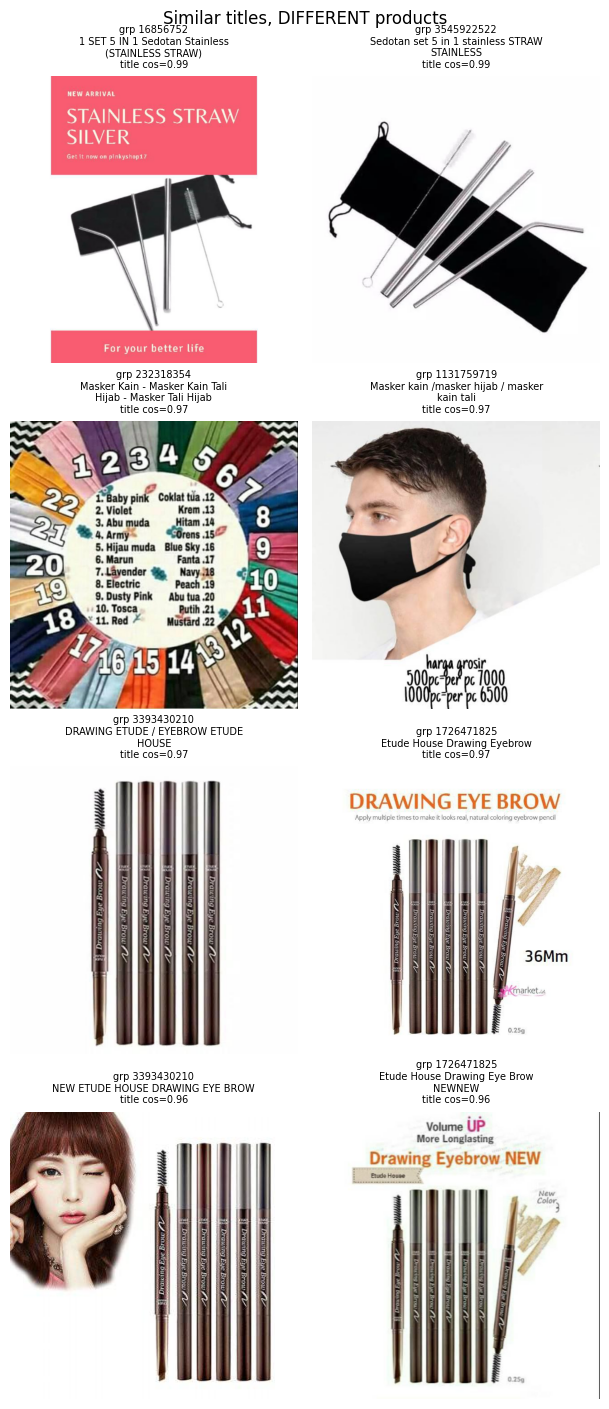


Only in A: ['(stainless', 'straw)']
Only in B: ['straw']

Only in A: ['-']
Only in B: ['/', '/masker']

Only in A: ['/']
Only in B: []

Only in A: ['new']
Only in B: ['newnew']


In [20]:
t_wrong = np.where((~t_hit) & (text_sim[:, 0] >= 0.6) & (text_sim[:, 0] < 0.999))[0]
t_wrong = t_wrong[np.argsort(-text_sim[t_wrong, 0])]
print(f"Anchors jinka top-1 title-neighbour cos>=0.6 hai par DIFFERENT product: {len(t_wrong)} / {N_ANCH}")

sel = t_wrong[:4]
pairs = [(anchors[a], text_nn[a, 0]) for a in sel]
show_pairs(pairs, "Similar titles, DIFFERENT products",
           [f"title cos={text_sim[a, 0]:.2f}" for a in sel])

for (i, j) in pairs:
    only_i, only_j = diff_tokens(i, j)
    print(f"\nOnly in A: {only_i}\nOnly in B: {only_j}")

Anchors jinka nearest pHash neighbour dist<=6 hai par DIFFERENT product: 98 / 3000


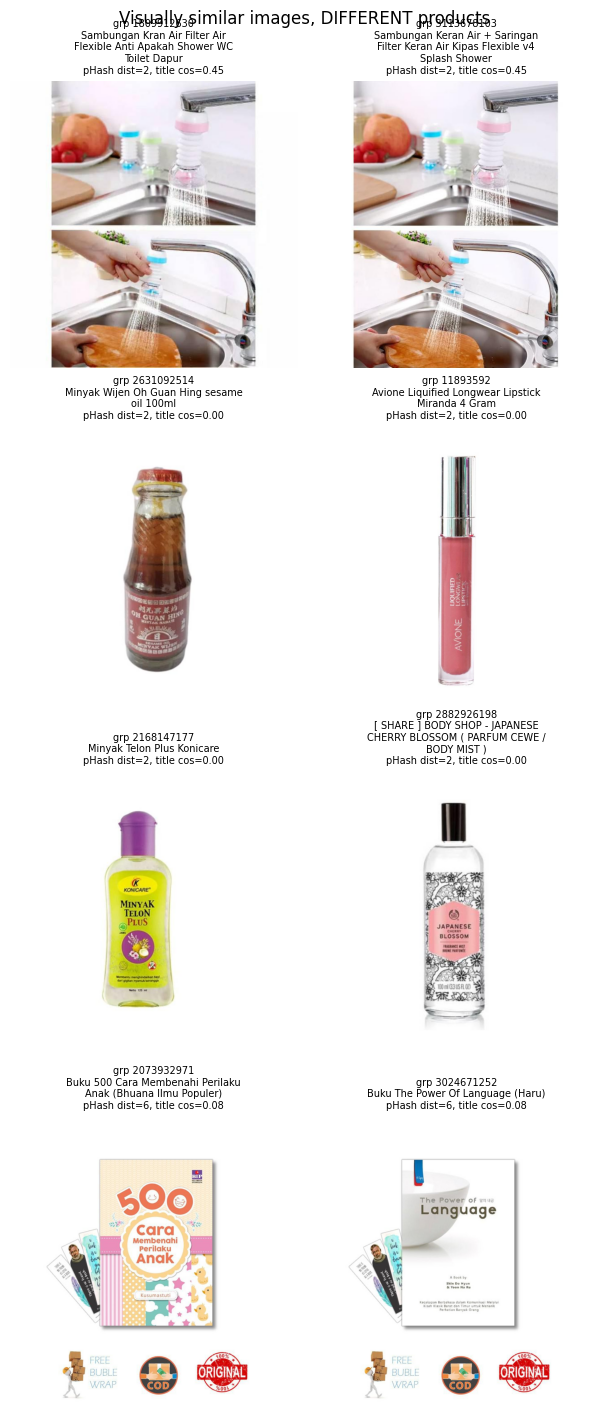

In [21]:
p_wrong = np.where((~p_hit) & (ph_dist[:, 0] <= 6))[0]
print(f"Anchors jinka nearest pHash neighbour dist<=6 hai par DIFFERENT product: {len(p_wrong)} / {N_ANCH}")

sel = rng.permutation(p_wrong)[:4]
pairs = [(anchors[a], ph_nn[a, 0]) for a in sel]
cs = pair_cos(np.array([p[0] for p in pairs]), np.array([p[1] for p in pairs])) if len(pairs) else []
show_pairs(pairs, "Visually similar images, DIFFERENT products",
           [f"pHash dist={int(ph_dist[a, 0])}, title cos={c:.2f}" for a, c in zip(sel, cs)])


=== very short (<=2 words): 543 rows (1.6%) ===
  - Followme Shampoo
  - Jaket TNF
  - Mukena SHAFEENA

=== very long (>=25 words): 138 rows (0.4%) ===
  - Soft Case Silikon Motif Kartun Kumis Warna Permen untuk Samsung A50 A31 A10S J7 Prime A51 J2 Prime A20S A11 A10 A21S A30 A50S A30S A20 M11 M
  - Casing Soft Case Koper Motif Chrysanthemum Putih untuk OPPO A53 2020 Reno 4 A5S A5 2020 A3S A92 A31 A12 A9 2020 F9 PRO A37 A37F F1S F11 A1K 
  - Case OPPO A53 A33 A52 A92 A31 A91 A5 A9 2020 A7 A5S A12 AX7 A1K A3S A12e F1S F11 Pro F9 F7 F5 Youth A83 A71 A39 A57 F3 Lite A37 A37F Reno 3 

=== mostly upper-case: 7255 rows (21.2%) ===
  - ( COD ) KEMEJA FLANEL LENGAN PANJANG PREMIUM
  - 1KG MUAT 3PCS | MOZY OVERALL / OVERALL LONG JEANS / LONG OVERALL JEANS WANITA
  - OMGENDUT MOBIL TAYOO ISI 4 PCS PULL BACK - MOBIL LITTLE BUS TAYO

=== many special chars (>15%): 97 rows (0.3%) ===
  - Playmat Termurah!!!
  - BRAVE HOODIE \xe2\x80\x9cUNISEX\xe2\x80\x9d(cowo/cewe)
  - \xe2\x9a\xa0\xef\xb8\x8f \xf

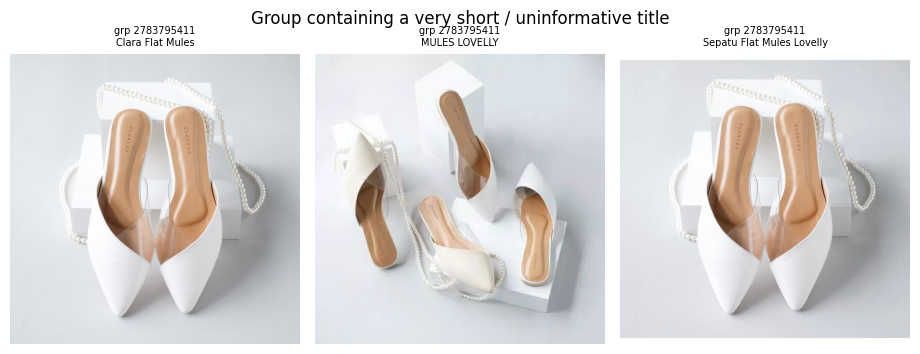

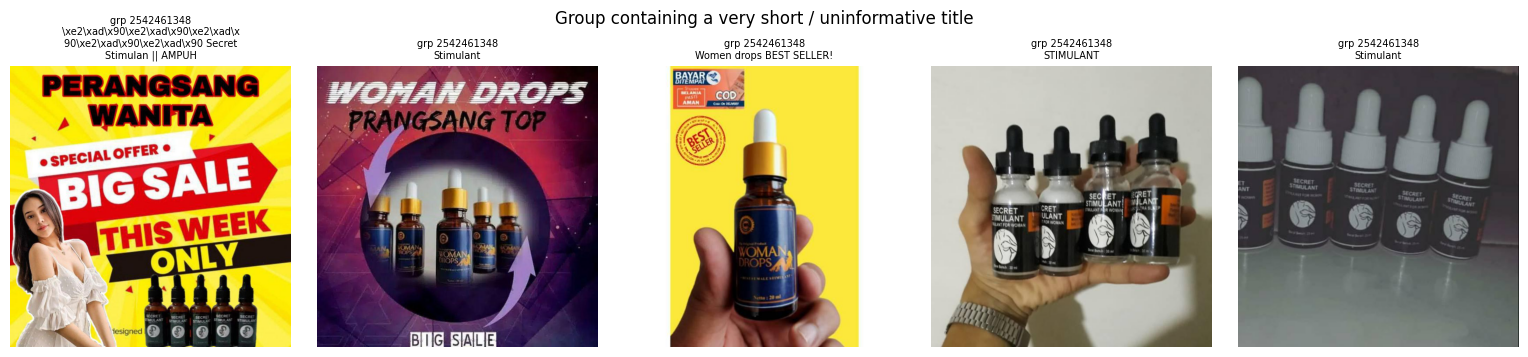

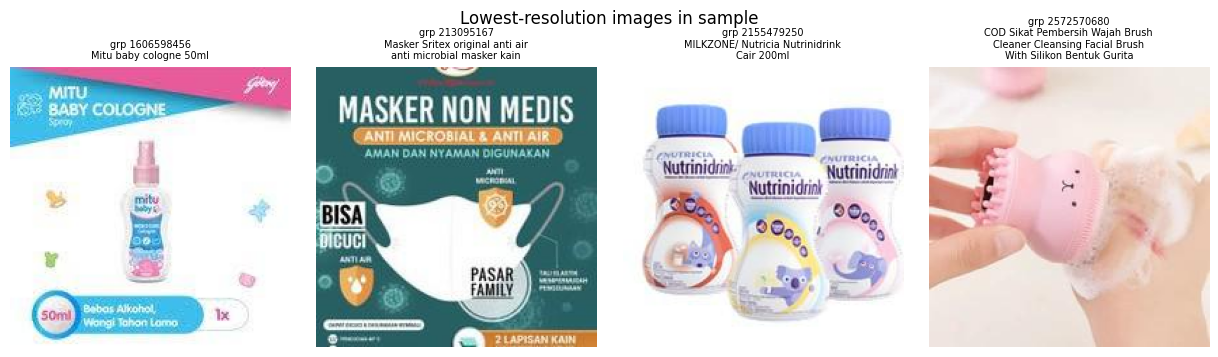

In [22]:
noisy = {
    "very short (<=2 words)":     train["n_words"] <= 2,
    "very long (>=25 words)":     train["n_words"] >= 25,
    "mostly upper-case":          train["upper_ratio"] > 0.8,
    "many special chars (>15%)":  train["special_ratio"] > 0.15,
    "promo / spam words":         train["has_promo"],
    "non-ASCII characters":       train["non_ascii"],
}
for name, mk in noisy.items():
    print(f"\n=== {name}: {mk.sum()} rows ({mk.mean():.1%}) ===")
    for t in train.loc[mk, "title"].sample(min(3, mk.sum()), random_state=SEED):
        print("  -", t[:140])

# Short title wale rows aur unke group siblings
short_idx = train.index[(train["n_words"] <= 2) & (train["label_group"].map(group_sizes) >= 3)]
for i in rng.choice(short_idx, 2, replace=False):
    idx = np.where(labels == labels[i])[0][:5]
    show_grid(idx, len(idx), "Group containing a very short / uninformative title")

# Sabse chhoti-resolution images
small = img_samp[np.argsort(np.minimum(img_w, img_h))[:4]]
show_grid(small, 4, "Lowest-resolution images in sample")

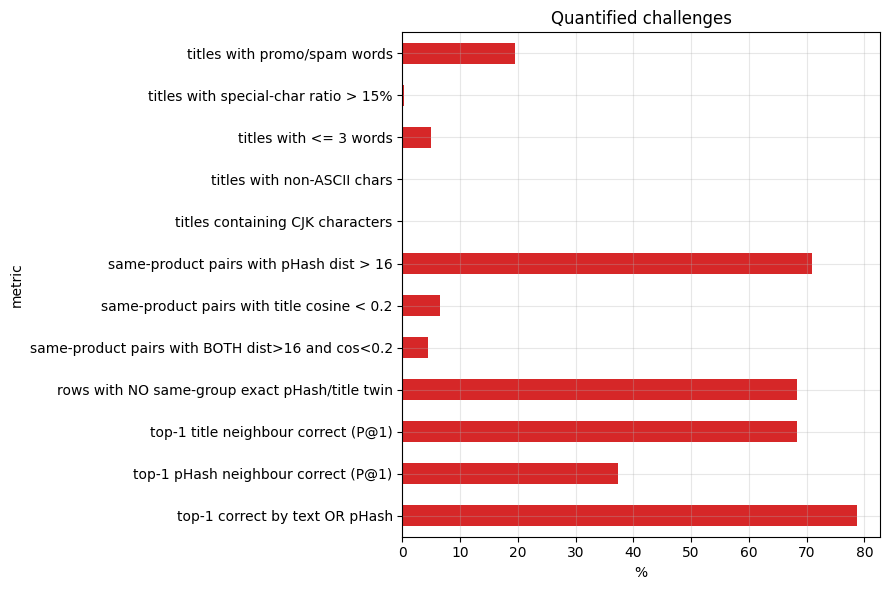

,challenge,metric,value
0,Noisy titles,titles with promo/spam words,19.5%
1,Noisy titles,titles with special-char ratio > 15%,0.3%
2,Missing information,titles with <= 3 words,5.0%
3,Language mix,titles with non-ASCII chars,0.0%
4,Language mix,titles containing CJK characters,0.0%
5,Image variation,same-product pairs with pHash dist > 16,70.9%
6,Title variation,same-product pairs with title cosine < 0.2,6.5%
7,Hardest positives,same-product pairs with BOTH dist>16 and cos<0.2,4.5%
8,Duplicate shortcuts,rows with NO same-group exact pHash/title twin,68.4%
9,Text alone,top-1 title neighbour correct (P@1),68.3%


In [23]:
challenge = pd.DataFrame([
    ("Noisy titles",        "titles with promo/spam words",                        train["has_promo"].mean()),
    ("Noisy titles",        "titles with special-char ratio > 15%",                (train["special_ratio"] > 0.15).mean()),
    ("Missing information", "titles with <= 3 words",                              (train["n_words"] <= 3).mean()),
    ("Language mix",        "titles with non-ASCII chars",                         train["non_ascii"].mean()),
    ("Language mix",        "titles containing CJK characters",                    train["has_cjk"].mean()),
    ("Image variation",     "same-product pairs with pHash dist > 16",             (pos_ham > 16).mean()),
    ("Title variation",     "same-product pairs with title cosine < 0.2",          (pos_cos < 0.2).mean()),
    ("Hardest positives",   "same-product pairs with BOTH dist>16 and cos<0.2",    ((pos_ham > 16) & (pos_cos < 0.2)).mean()),
    ("Duplicate shortcuts", "rows with NO same-group exact pHash/title twin",      1 - train["any_twin"].mean()),
    ("Text alone",          "top-1 title neighbour correct (P@1)",                 text_p1),
    ("Image hash alone",    "top-1 pHash neighbour correct (P@1)",                 ph_p1),
    ("Combined",            "top-1 correct by text OR pHash",                      either),
], columns=["challenge", "metric", "value"])

ax = (challenge.set_index("metric")["value"] * 100)[::-1].plot.barh(figsize=(9, 6), color="tab:red")
ax.set_xlabel("%"); ax.set_title("Quantified challenges"); plt.tight_layout(); plt.show()

out = challenge.copy()
out["value"] = (out["value"] * 100).round(1).astype(str) + "%"
out